In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

from scipy.stats import ttest_ind, mannwhitneyu
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)

In [2]:
DATA_PATH = Path(
    "data/ProteoSAFe-MAESTRO-d6178bdd-identified_variants_merged_protein_regions/"
    "MAESTRO-d6178bdd-identified_variants_merged_protein_regions-main.tsv"
)

PROCESSED_DIR = Path("data/processed/stage2")

TASK_NAMES = [
    "healthy_vs_infected",
    "symptomatic_non_covid_vs_covid",
    "severe_vs_nonsevere",
]

INTENSITY_SUFFIX = "_intensity_for_peptide_variant"

In [3]:
raw_df = pd.read_csv(DATA_PATH, sep="\t")

print("Raw shape:", raw_df.shape)
print(raw_df.columns[:30].tolist())

Raw shape: (101461, 268)
['rowid', 'ccms_row_id', 'Algorithm', 'Filename', 'Cluster_index', 'Peptide', 'Unmodified_sequence', 'Charge', '_dyn_#Intensity_for_cluster', '_dyn_#Intensity_for_unmodified_sequence', 'Num_G1_spectra_for_unmodified_sequence', 'Num_G2_spectra_for_unmodified_sequence', 'Num_G3_spectra_for_unmodified_sequence', 'Num_G4_spectra_for_unmodified_sequence', 'Num_G5_spectra_for_unmodified_sequence', 'Num_G6_spectra_for_unmodified_sequence', '_dyn_#Empty.Empty.Empty..Empty.1_intensity_for_unmodified_sequence', '_dyn_#Healthy.HC1.Healthy..HC1.1_intensity_for_unmodified_sequence', '_dyn_#Healthy.HC10.Healthy..HC10.1_intensity_for_unmodified_sequence', '_dyn_#Healthy.HC12.Healthy..HC12.1_intensity_for_unmodified_sequence', '_dyn_#Healthy.HC13.Healthy..HC13.1_intensity_for_unmodified_sequence', '_dyn_#Healthy.HC17.Healthy..HC17.1_intensity_for_unmodified_sequence', '_dyn_#Healthy.HC19.Healthy..HC19.1_intensity_for_unmodified_sequence', '_dyn_#Healthy.HC2.Healthy..HC2.1_inte

C:\Users\Selina\AppData\Local\Temp\ipykernel_27480\3840097549.py:1: DtypeWarning: Columns (0: DrugBank_drugs) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv(DATA_PATH, sep="\t")


Rebuild preprocessing matrices

In [4]:
# Select intensity columns
intensity_cols = [col for col in raw_df.columns if col.endswith(INTENSITY_SUFFIX)]
peptide_df = raw_df[["Peptide", *intensity_cols]].copy()

print(f"Peptide rows: {peptide_df.shape[0]:,}")
print(f"Intensity columns: {len(intensity_cols):,}")


def parse_intensity_column(col: str) -> dict:
    prefix = col.removeprefix("_dyn_#").removesuffix(INTENSITY_SUFFIX)
    parts = prefix.split(".")
    return {
        "original_column": col,
        "condition": parts[0],
        "sample_id": parts[1],
    }


sample_metadata = pd.DataFrame([parse_intensity_column(col) for col in intensity_cols])

# Remove controls
CONTROL_CONDITIONS = {"Empty", "Norm"}

patient_metadata = sample_metadata[
    ~sample_metadata["condition"].isin(CONTROL_CONDITIONS)
].copy()

patient_cols = patient_metadata["original_column"].tolist()

patient_peptide_df = peptide_df[["Peptide", *patient_cols]].copy()

print("Patient samples:", len(patient_cols))
print(patient_metadata["condition"].value_counts())

Peptide rows: 101,461
Intensity columns: 92
Patient samples: 90
condition
Non-severe-COVID-19         25
Symptomatic-non-COVID-19    25
Healthy                     22
Severe-COVID-19             18
Name: count, dtype: int64


In [5]:
# Zero to NaN, missingness filtering, imputation, log1p

# Peptides x samples
intensity_matrix = patient_peptide_df.set_index("Peptide")
intensity_matrix = intensity_matrix.apply(pd.to_numeric, errors="coerce")

# Convert zeros to NaN
zero_count = (intensity_matrix == 0).sum().sum()
missing_matrix_full = intensity_matrix.replace(0, np.nan)

print(f"Zeros converted to NaN: {zero_count:,}")
print(f"Missing values after zero replacement: {missing_matrix_full.isna().sum().sum():,}")

# Filter peptides with >50% missingness
MISSINGNESS_THRESHOLD = 0.50

missing_fraction_by_peptide = missing_matrix_full.isna().mean(axis=1)
keep_peptides = missing_fraction_by_peptide <= MISSINGNESS_THRESHOLD

filtered_missing_matrix = missing_matrix_full.loc[keep_peptides].copy()

print(f"Peptides before filtering: {missing_matrix_full.shape[0]:,}")
print(f"Peptides after filtering: {filtered_missing_matrix.shape[0]:,}")
print(f"Peptides removed: {(~keep_peptides).sum():,}")

# Impute missing as 0 and log1p transform
imputed_matrix = filtered_missing_matrix.fillna(0)
log_matrix = np.log1p(imputed_matrix)

# Transpose: samples x peptides
sample_missing_matrix = filtered_missing_matrix.T
sample_missing_matrix.index.name = "original_column"

sample_log_matrix = log_matrix.T
sample_log_matrix.index.name = "original_column"

print("sample_missing_matrix:", sample_missing_matrix.shape)
print("sample_log_matrix:", sample_log_matrix.shape)

Zeros converted to NaN: 5,363,463
Missing values after zero replacement: 5,410,263
Peptides before filtering: 101,461
Peptides after filtering: 35,882
Peptides removed: 65,579
sample_missing_matrix: (90, 35882)
sample_log_matrix: (90, 35882)


Add sample metadata

In [7]:
sample_metadata_indexed = patient_metadata.set_index("original_column")[["condition", "sample_id"]]

model_log_df = sample_log_matrix.merge(
    sample_metadata_indexed,
    left_index=True,
    right_index=True,
)

model_missing_df = sample_missing_matrix.merge(
    sample_metadata_indexed,
    left_index=True,
    right_index=True,
)

print(model_log_df.shape)
model_log_df.head()

(90, 35884)


,K.[304.207]LYQPEYQEVSTEEQR.E,"K.[304.207]H(G,304.213)TDDGVVWMNW(K,304.207).G","R.[304.207]DDTV(C,57.021)LA(K,304.207)LHDR.N","R.[304.207]QQQHLFGSNVTD(C,57.021)SGNF(C,57.021)LFR.S","-.[304.207](Q,-17.027)QQHLFGSNVTD(C,57.021)SGNF(C,57.021)LFR.S","K.[304.207]DLLFRDDTV(C,57.021)L(A,304.58)(K,304.207).L","R.[304.207]DDTV(C,57.021)LA(K,632.887)LHDR.N","R.[304.207]QQQHL(F,305.275)GSNVTD(C,57.021)SGNF(C,57.021)LFR.S","R.[304.207]QQQHLF(G,304.219)SNVTD(C,57.021)SGNF(C,57.021)LFR.S","R.[304.207]DDTV(C,57.021)(L,21.982)A(K,304.207).L","K.[304.207]DLLFRDDTV(C,57.021)(L,134.957)A(K,304.207).L","R.[304.207]DDTV(C,58.003)LA(K,304.207).L","K.{42.995}[304.207]DLLFRDDTV(C,57.021)LA(K,304.207).L","D.[304.207](C,57.021)SGNF(C,57.021)LFR.S","R.[304.207]SET(K,304.207)DLLFRDDTV(C,57.021)LA(K,304.207).L","K.[304.207](D,15.017)LLFRDDTV(C,57.021)LA(K,304.207).L","K.[304.207]DLLFRDDTV(C,47.994)LA(K,304.207).L","K.[304.207]DLLF(R,-18.004)DDTV(C,57.021)LA(K,304.207).L","R.[304.207]SET(K,177.076)DLLFRDDTV(C,57.021)LA(K,304.207).L","S.[304.207](E,-60.128)T(K,304.207)DLLFRDDTV(C,57.021)LA(K,304.207).L","K.[304.207]DLLFRDDTV(C,57.021)LA(K,199.1199).L","R.[304.207]QQQHL(F,-77.729)GSNVTD(C,57.021)SGNF(C,57.021)LFR.S","E.[304.207](T,-31.101)(K,304.207)DLLFRDDTV(C,57.021)LA(K,304.207).L","R.[304.207]DDTV(C,57.021)LA(K,241.075)LHDR.N","D.[215.050]LLFRDDTV(C,57.021)LA(K,304.207).L",...,"K.[304.207](Y,-4.4)LGEEYV(K,304.207).A","K.[304.207](Y,-28.074)LGEEYV(K,304.207).A","K.[304.207](Y,-57.07)LGEEYV(K,304.207).A","K.[304.207]YLGEEYV(K,277.059)AVGNLR.K","Y.[304.207]E(K,263.069)YLGEEYV(K,304.207).A","K.[304.207]YLGEEYV(K,304.207)AVGNLR(K,304.207)(C,57.021).S","K.[304.207]YLGEEYV(K,177.072)AVGNLR.K","K.[304.207]YLGEEYV(K,421.795)AVGNLR(K,304.207).C","K.[304.207](Y,347.65)LGEEYV(K,304.207).A","K.[304.207](Y,291.172)LGEEYV(K,304.207).A","K.[304.207]YLGEEY(V,128.488)(K,304.207).A","K.{101.467}[304.207]YLGEEYV(K,304.207).A","K.{57.001}[304.207]YLGEEYV(K,304.207).A","K.{53.914}[304.207]YLGEEYV(K,304.207).A","K.{52.915}[304.207]YLGEEYV(K,304.207).A","K.[304.207]YLGE(E,31.996)YV(K,304.207).A","K.[304.207]YLGEE(Y,21.985)V(K,304.207).A","K.[304.207]YLGE(E,14.998)YV(K,304.207).A","K.[304.207]YL(G,13.987)EEYV(K,304.207).A","K.[304.207]YLGEEYV(K,302.195).A","K.[304.207]YLGEEY(V,-18.002)(K,304.207).A","K.[304.207]YLGEE(Y,-20.114)V(K,304.207).A","K.[304.207]YLGEE(Y,-57.005)V(K,304.207).A",condition,sample_id
original_column,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
_dyn_#Healthy.HC1.Healthy..HC1.1_intensity_for_peptide_variant,0.660581,0.253728,0.000000,0.096477,0.841409,0.000000,0.000000,0.000000,0.855375,0.000000,0.241007,0.149626,0.441116,0.000000,0.027870,0.000000,0.000000,0.604188,0.000000,0.00000,0.000000,0.429738,0.000000,0.000000,0.527678,...,0.760700,0.569108,1.652323,0.000000,0.921661,0.290591,0.000000,0.573312,0.132651,1.255983,0.293329,0.000000,0.429996,0.630807,0.443559,0.244423,0.654389,0.000000,0.187094,0.357646,0.338294,0.454854,1.084792,Healthy,HC1
_dyn_#Healthy.HC10.Healthy..HC10.1_intensity_for_peptide_variant,0.000000,0.025691,0.000000,0.191623,0.631683,0.309955,0.000000,0.550178,0.312313,0.323958,0.259936,0.431112,0.000000,0.529874,0.234585,0.484572,0.000000,0.357425,0.497750,0.00000,0.606206,0.164299,0.452574,0.723369,0.946649,...,0.000000,0.000000,1.189384,0.432583,0.546137,0.506515,0.456701,0.000000,0.081940,1.235533,0.388862,0.230301,1.293513,0.000000,0.684840,0.000000,0.908099,0.078225,0.259012,0.732251,0.309250,0.329653,1.265440,Healthy,HC10
_dyn_#Healthy.HC12.Healthy..HC12.1_intensity_for_peptide_variant,0.000000,0.008992,0.000000,0.090532,0.328496,0.171289,0.000000,0.318865,0.161258,0.187374,0.138016,0.276602,0.000000,0.313619,0.123498,0.444648,0.000000,0.198572,0.338685,0.00000,0.322104,0.068703,0.161511,0.294056,0.356724,...,0.000000,0.000000,0.187271,0.353779,0.245459,0.177736,0.272322,0.000000,0.038548,0.279245,0.185829,0.116185,0.798531,0.000000,0.406481,0.000000,0.533243,0.048059,0.138023,0.430190,0.155832,0.179494,0.648777,Healthy,HC12
_

In [8]:
# Define task labels
TASK_CONFIGS = {
    "healthy_vs_infected": {
        "positive_conditions": [
            "Non-severe-COVID-19",
            "Severe-COVID-19",
            "Symptomatic-non-COVID-19",
        ],
        "negative_conditions": ["Healthy"],
        "positive_label": "Infected",
        "negative_label": "Healthy",
    },
    "symptomatic_non_covid_vs_covid": {
        "positive_conditions": ["Non-severe-COVID-19", "Severe-COVID-19"],
        "negative_conditions": ["Symptomatic-non-COVID-19"],
        "positive_label": "COVID-19",
        "negative_label": "Symptomatic-non-COVID-19",
    },
    "severe_vs_nonsevere": {
        "positive_conditions": ["Severe-COVID-19"],
        "negative_conditions": ["Non-severe-COVID-19"],
        "positive_label": "Severe-COVID-19",
        "negative_label": "Non-severe-COVID-19",
    },
}


def make_task_data(task_name, config):
    task_conditions = config["negative_conditions"] + config["positive_conditions"]
    
    log_df = model_log_df[model_log_df["condition"].isin(task_conditions)].copy()
    missing_df = model_missing_df[model_missing_df["condition"].isin(task_conditions)].copy()
    
    y = log_df["condition"].isin(config["positive_conditions"]).astype(int)
    
    metadata = log_df[["sample_id", "condition"]].copy()
    metadata["label"] = y
    metadata["label_name"] = np.where(
        y.eq(1),
        config["positive_label"],
        config["negative_label"],
    )
    
    feature_cols = [c for c in log_df.columns if c not in {"condition", "sample_id"}]
    
    X_log = log_df[feature_cols].copy()
    X_missing = missing_df[feature_cols].copy()
    
    return {
        "X_log": X_log,
        "X_missing": X_missing,
        "y": y,
        "metadata": metadata,
        "config": config,
    }


task_data = {
    task_name: make_task_data(task_name, config)
    for task_name, config in TASK_CONFIGS.items()
}

for task_name, data in task_data.items():
    print("\n", task_name)
    print(data["X_log"].shape)
    print(data["metadata"]["label_name"].value_counts())


 healthy_vs_infected
(90, 35882)
label_name
Infected    68
Healthy     22
Name: count, dtype: int64

 symptomatic_non_covid_vs_covid
(68, 35882)
label_name
COVID-19                    43
Symptomatic-non-COVID-19    25
Name: count, dtype: int64

 severe_vs_nonsevere
(43, 35882)
label_name
Non-severe-COVID-19    25
Severe-COVID-19        18
Name: count, dtype: int64


In [10]:
# Create top feature table
top_features = pd.read_csv(PROCESSED_DIR / "top_lr_features.csv")
top_features.head()

,task,rank,peptide_variant,coefficient
0,healthy_vs_infected,1,"K.[304.207]SLHTLFGD(K,332.213)L(C,57.021)TVA.T",0.44
1,healthy_vs_infected,2,"K.[304.207](C,57.021)(C,57.021)AAADPHE.C",0.40
2,healthy_vs_infected,3,"D.[304.207](K,203.075)SLHTLFGD(K,304.207).L",0.40
3,healthy_vs_infected,4,"K.[304.207]L(K,331.18)E(C,57.021)(C,57.021)E(K...",0.29
4,healthy_vs_infected,5,"K.[304.207]ADSVVDLLSYNV(Q,303.212)GSGETTYDH(K,...",0.26


In [11]:
# Check whether top peptides exist in the feature matrix
missing_features = []

for _, row in top_features.iterrows():
    task = row["task"]
    peptide = row["peptide_variant"]
    
    X_log = task_data[task]["X_log"]
    
    if peptide not in X_log.columns:
        missing_features.append((task, row["rank"], peptide))

print("Number of top features not found:", len(missing_features))

for item in missing_features:
    print(item)

Number of top features not found: 0


## Part A：Missingness analysis

In [12]:
# Compute missingness for top peptides
def compute_missingness_for_task(task_name, top_features_task, X_missing, y, config):
    rows = []
    
    for _, row in top_features_task.iterrows():
        peptide = row["peptide_variant"]
        
        if peptide not in X_missing.columns:
            rows.append({
                "task": task_name,
                "rank": row["rank"],
                "peptide_variant": peptide,
                "coefficient": row["coefficient"],
                "status": "feature_not_found"
            })
            continue
        
        values = X_missing[peptide]
        
        class0 = values[y == 0]
        class1 = values[y == 1]
        
        class0_missing_rate = class0.isna().mean()
        class1_missing_rate = class1.isna().mean()
        
        class0_detection_rate = 1 - class0_missing_rate
        class1_detection_rate = 1 - class1_missing_rate
        
        missingness_diff = class1_missing_rate - class0_missing_rate
        
        if class0_missing_rate > 0.5 or class1_missing_rate > 0.5:
            flag = "high_missingness"
        elif abs(missingness_diff) > 0.3:
            flag = "detection_driven"
        else:
            flag = "acceptable"
        
        rows.append({
            "task": task_name,
            "rank": row["rank"],
            "peptide_variant": peptide,
            "coefficient": row["coefficient"],
            "class0_label": config["negative_label"],
            "class1_label": config["positive_label"],
            "class0_n": len(class0),
            "class1_n": len(class1),
            "class0_missing_rate": class0_missing_rate,
            "class1_missing_rate": class1_missing_rate,
            "class0_detection_rate": class0_detection_rate,
            "class1_detection_rate": class1_detection_rate,
            "missingness_diff_class1_minus_class0": missingness_diff,
            "missingness_flag": flag,
            "status": "ok",
        })
    
    return pd.DataFrame(rows)

In [13]:
missingness_results = []

for task_name in TASK_NAMES:
    data = task_data[task_name]
    top_task = top_features[top_features["task"] == task_name]
    
    result = compute_missingness_for_task(
        task_name=task_name,
        top_features_task=top_task,
        X_missing=data["X_missing"],
        y=data["y"],
        config=data["config"],
    )
    
    missingness_results.append(result)

missingness_df = pd.concat(missingness_results, ignore_index=True)

missingness_df.to_csv(
    PROCESSED_DIR / "missingness_top_peptides.csv",
    index=False
)

missingness_df

,task,rank,peptide_variant,coefficient,class0_label,class1_label,class0_n,class1_n,class0_missing_rate,class1_missing_rate,class0_detection_rate,class1_detection_rate,missingness_diff_class1_minus_class0,missingness_flag,status
0,healthy_vs_infected,1,"K.[304.207]SLHTLFGD(K,332.213)L(C,57.021)TVA.T",0.44,Healthy,Infected,22,68,0.000000,0.000000,1.000000,1.000000,0.000000,acceptable,ok
1,healthy_vs_infected,2,"K.[304.207](C,57.021)(C,57.021)AAADPHE.C",0.40,Healthy,Infected,22,68,0.045455,0.000000,0.954545,1.000000,-0.045455,acceptable,ok
2,healthy_vs_infected,3,"D.[304.207](K,203.075)SLHTLFGD(K,304.207).L",0.40,Healthy,Infected,22,68,0.000000,0.000000,1.000000,1.000000,0.000000,acceptable,ok
3,healthy_vs_infected,4,"K.[304.207]L(K,331.18)E(C,57.021)(C,57.021)E(K...",0.29,Healthy,Infected,22,68,0.000000,0.000000,1.000000,1.000000,0.000000,acceptable,ok
4,healthy_vs_infected,5,"K.[304.207]ADSVVDLLSYNV(Q,303.212)GSGETTYDH(K,...",0.26,Healthy,Infected,22,68,0.000000,0.000000,1.000000,1.000000,0.000000,acceptable,ok
5,healthy_vs_infected,6,"S.[304.207]IGYADSV(K,304.207).G",0.26,Healthy,Infected,22,68,0.000000,0.000000,1.000000,1.000000,0.000000,acceptable,ok
6,healthy_vs_infected,7,"R.[304.207]TLADLTLLDSPI(K,304.207).V",0.24,Healthy,Infected,22,68,0.000000,0.000000,1.000000,1.000000,0.000000,acceptable,ok
7,healthy_vs_infected,8,"K.[304.207](K,376.233)VPQVSTPTLVEVSR.N",0.22,Healthy,Infected,22,68,0.000000,0.000000,1.000000,1.000000,0.000000,acceptable,ok
8,healthy_vs_infected,9,"S.[236.123]LHTLFGD(K,304.207).L",0.20,Healthy,Infected,22,68,0.045455,0.000000,0.954545,1.000000,-0.045455,acceptable,ok
9,healthy_vs_infected,10,"F.[304.207](K,291.14)DLGEENF(K,304.207).A",0.19,Healthy,Infected,22,68,0.000000,0.000000,1.000000,1.000000,0.000000,acceptable,ok


## Part B：Peptide/variant-level DA tests

Run Welch’s t-test and Mann-Whitney U test

In [14]:
def run_peptide_da_for_task(task_name, top_features_task, X_log, X_missing, y, config, missingness_df_task):
    rows = []
    
    for _, row in top_features_task.iterrows():
        peptide = row["peptide_variant"]
        
        if peptide not in X_log.columns:
            rows.append({
                "task": task_name,
                "rank": row["rank"],
                "peptide_variant": peptide,
                "coefficient": row["coefficient"],
                "status": "feature_not_found",
            })
            continue
        
        values = X_log[peptide]
        
        group0 = values[y == 0].dropna()
        group1 = values[y == 1].dropna()
        
        if len(group0) < 2 or len(group1) < 2:
            rows.append({
                "task": task_name,
                "rank": row["rank"],
                "peptide_variant": peptide,
                "coefficient": row["coefficient"],
                "status": "too_few_values",
            })
            continue
        
        # Welch's t-test
        t_stat, t_p = ttest_ind(group0, group1, equal_var=False)
        
        # Mann-Whitney U test = independent two-sample Wilcoxon rank-sum style test
        u_stat, u_p = mannwhitneyu(group0, group1, alternative="two-sided")
        
        mean0 = group0.mean()
        mean1 = group1.mean()
        median0 = group0.median()
        median1 = group1.median()
        diff = mean1 - mean0
        
        if diff > 0:
            direction = f"higher_in_{config['positive_label']}"
        elif diff < 0:
            direction = f"higher_in_{config['negative_label']}"
        else:
            direction = "no_difference"
        
        miss_row = missingness_df_task[
            missingness_df_task["peptide_variant"] == peptide
        ]
        
        if len(miss_row) > 0:
            missingness_flag = miss_row.iloc[0]["missingness_flag"]
            class0_missing_rate = miss_row.iloc[0]["class0_missing_rate"]
            class1_missing_rate = miss_row.iloc[0]["class1_missing_rate"]
        else:
            missingness_flag = "unknown"
            class0_missing_rate = np.nan
            class1_missing_rate = np.nan
        
        rows.append({
            "task": task_name,
            "rank": row["rank"],
            "peptide_variant": peptide,
            "coefficient": row["coefficient"],
            "class0_label": config["negative_label"],
            "class1_label": config["positive_label"],
            "class0_n": len(group0),
            "class1_n": len(group1),
            "class0_mean_log1p": mean0,
            "class1_mean_log1p": mean1,
            "class0_median_log1p": median0,
            "class1_median_log1p": median1,
            "mean_diff_class1_minus_class0": diff,
            "direction": direction,
            "t_stat": t_stat,
            "t_test_p": t_p,
            "mannwhitney_u": u_stat,
            "mannwhitney_p": u_p,
            "class0_missing_rate": class0_missing_rate,
            "class1_missing_rate": class1_missing_rate,
            "missingness_flag": missingness_flag,
            "status": "ok",
        })
    
    result_df = pd.DataFrame(rows)
    
    ok_mask = result_df["status"] == "ok"
    
    result_df["t_test_fdr"] = np.nan
    result_df["mannwhitney_fdr"] = np.nan
    
    if ok_mask.sum() > 0:
        result_df.loc[ok_mask, "t_test_fdr"] = multipletests(
            result_df.loc[ok_mask, "t_test_p"].fillna(1.0),
            method="fdr_bh"
        )[1]
        
        result_df.loc[ok_mask, "mannwhitney_fdr"] = multipletests(
            result_df.loc[ok_mask, "mannwhitney_p"].fillna(1.0),
            method="fdr_bh"
        )[1]
    
    def call_da(r):
        if r["status"] != "ok":
            return "not_evaluable"
        
        stat_sig = (r["t_test_p"] < 0.05) or (r["mannwhitney_p"] < 0.05)
        fdr_sig = (
            pd.notna(r["t_test_fdr"]) and r["t_test_fdr"] < 0.05
        ) or (
            pd.notna(r["mannwhitney_fdr"]) and r["mannwhitney_fdr"] < 0.05
        )
        
        if r["missingness_flag"] in ["high_missingness", "detection_driven"]:
            if stat_sig:
                return "weak_DA_missingness_caution"
            return "not_DA_missingness_caution"
        
        if fdr_sig:
            return "strong_DA_FDR"
        if stat_sig:
            return "moderate_DA_nominal"
        return "not_DA"
    
    result_df["DA_call"] = result_df.apply(call_da, axis=1)
    
    return result_df

In [15]:
da_results = []

for task_name in TASK_NAMES:
    data = task_data[task_name]
    top_task = top_features[top_features["task"] == task_name]
    missing_task = missingness_df[missingness_df["task"] == task_name]
    
    result = run_peptide_da_for_task(
        task_name=task_name,
        top_features_task=top_task,
        X_log=data["X_log"],
        X_missing=data["X_missing"],
        y=data["y"],
        config=data["config"],
        missingness_df_task=missing_task,
    )
    
    da_results.append(result)

peptide_da_df = pd.concat(da_results, ignore_index=True)

peptide_da_df.to_csv(
    PROCESSED_DIR / "peptide_variant_DA_results.csv",
    index=False
)

peptide_da_df

,task,rank,peptide_variant,coefficient,class0_label,class1_label,class0_n,class1_n,class0_mean_log1p,class1_mean_log1p,class0_median_log1p,class1_median_log1p,mean_diff_class1_minus_class0,direction,t_stat,t_test_p,mannwhitney_u,mannwhitney_p,class0_missing_rate,class1_missing_rate,missingness_flag,status,t_test_fdr,mannwhitney_fdr,DA_call
0,healthy_vs_infected,1,"K.[304.207]SLHTLFGD(K,332.213)L(C,57.021)TVA.T",0.44,Healthy,Infected,22,68,0.312143,0.049858,0.299432,0.016282,-0.262285,higher_in_Healthy,9.130116,2.348645e-09,1436.0,1.084253e-10,0.000000,0.000000,acceptable,ok,5.871611e-09,1.084253e-09,strong_DA_FDR
1,healthy_vs_infected,2,"K.[304.207](C,57.021)(C,57.021)AAADPHE.C",0.40,Healthy,Infected,22,68,0.661065,0.148631,0.436150,0.101691,-0.512433,higher_in_Healthy,4.199347,3.783922e-04,1220.0,9.565974e-06,0.045455,0.000000,acceptable,ok,4.204358e-04,9.565974e-06,strong_DA_FDR
2,healthy_vs_infected,3,"D.[304.207](K,203.075)SLHTLFGD(K,304.207).L",0.40,Healthy,Infected,22,68,0.055877,0.010760,0.029656,0.007426,-0.045118,higher_in_Healthy,4.417698,2.243013e-04,1339.0,2.956214e-08,0.000000,0.000000,acceptable,ok,2.803766e-04,7.390534e-08,strong_DA_FDR
3,healthy_vs_infected,4,"K.[304.207]L(K,331.18)E(C,57.021)(C,57.021)E(K...",0.29,Healthy,Infected,22,68,0.133030,0.025816,0.100841,0.019358,-0.107214,higher_in_Healthy,4.146649,4.410105e-04,1371.0,5.082513e-09,0.000000,0.000000,acceptable,ok,4.410105e-04,1.694171e-08,strong_DA_FDR
4,healthy_vs_infected,5,"K.[304.207]ADSVVDLLSYNV(Q,303.212)GSGETTYDH(K,...",0.26,Healthy,Infected,22,68,0.111080,0.369397,0.083330,0.293272,0.258317,higher_in_Infected,-7.420132,6.984882e-11,182.0,1.100510e-07,0.000000,0.000000,acceptable,ok,2.328294e-10,1.572156e-07,strong_DA_FDR
5,healthy_vs_infected,6,"S.[304.207]IGYADSV(K,304.207).G",0.26,Healthy,Infected,22,68,0.463605,0.146451,0.435270,0.090046,-0.317154,higher_in_Healthy,5.174549,2.279782e-05,1269.0,1.024864e-06,0.000000,0.000000,acceptable,ok,3.256832e-05,1.138737e-06,strong_DA_FDR
6,healthy_vs_infected,7,"R.[304.207]TLADLTLLDSPI(K,304.207).V",0.24,Healthy,Infected,22,68,0.085645,0.363871,0.078557,0.338882,0.278226,higher_in_Infected,-8.240174,2.150113e-12,215.0,5.748889e-07,0.000000,0.000000,acceptable,ok,1.075056e-11,7.186111e-07,strong_DA_FDR
7,healthy_vs_infected,8,"K.[304.207](K,376.233)VPQVSTPTLVEVSR.N",0.22,Healthy,Infected,22,68,0.068948,0.407123,0.061507,0.341548,0.338174,higher_in_Infected,-8.922063,1.376836e-13,111.0,2.288385e-09,0.000000,0.000000,acceptable,ok,1.376836e-12,1.144192e-08,strong_DA_FDR
8,healthy_vs_infected,9,"S.[236.123]LHTLFGD(K,304.207).L",0.20,Healthy,Infected,22,68,1.385277,2.982079,1.077228,3.150717,1.596803,higher_in_Infected,-7.009668,4.207006e-08,171.0,6.212692e-08,0.045455,0.000000,acceptable,ok,7.011677e-08,1.149770e-07,strong_DA_FDR
9,healthy_vs_infected,10,"F.[304.207](K,291.14)DLGEENF(K,304.207).A",0.19,Healthy,Infected,22,68,1.599827,0.615887,1.550966,0.492125,-0.983939,higher_in_Healthy,7.026036,2.611634e-08,1323.0,6.898622e-08,0.000000,0.000000,acceptable,ok,5.223268e-08,1.149770e-07,strong_DA_FDR


## Part C：Plots

Detection rate bar plot

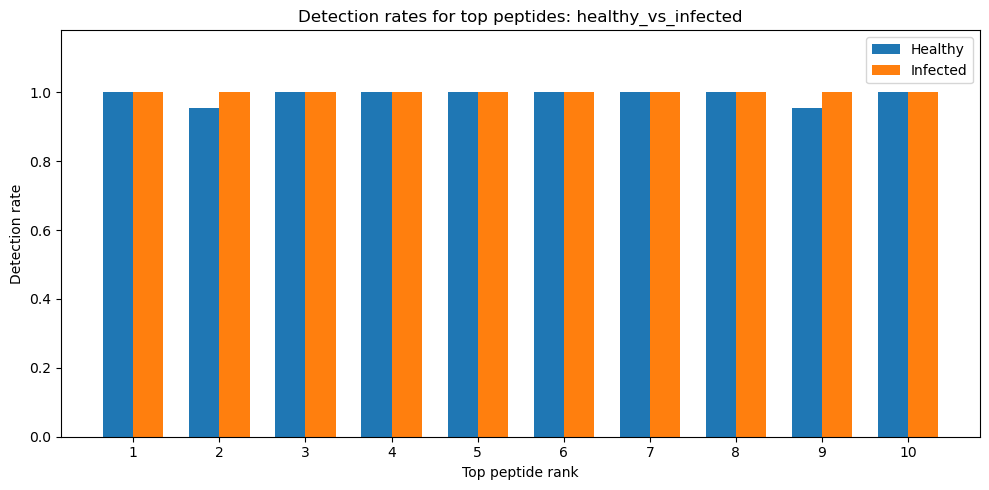

Saved: data\processed\stage2\healthy_vs_infected_top_peptides_detection_rates.png


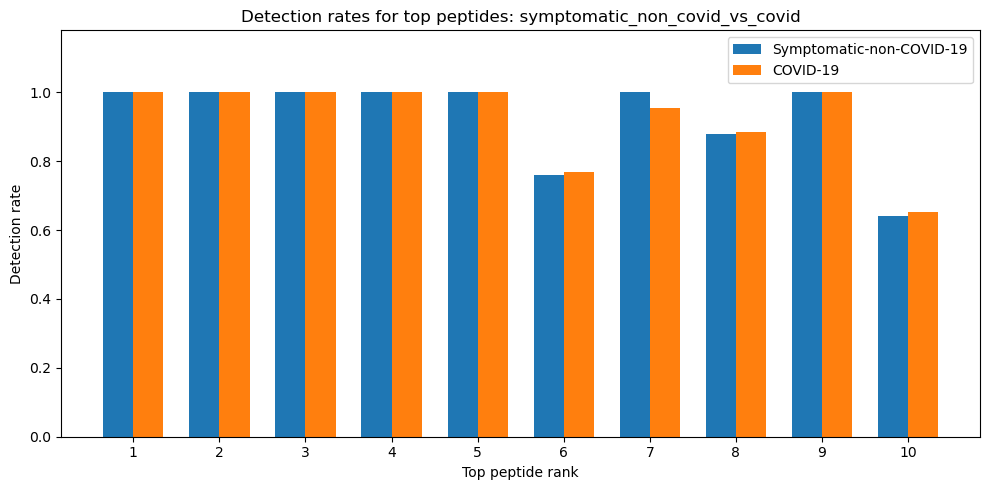

Saved: data\processed\stage2\symptomatic_non_covid_vs_covid_top_peptides_detection_rates.png


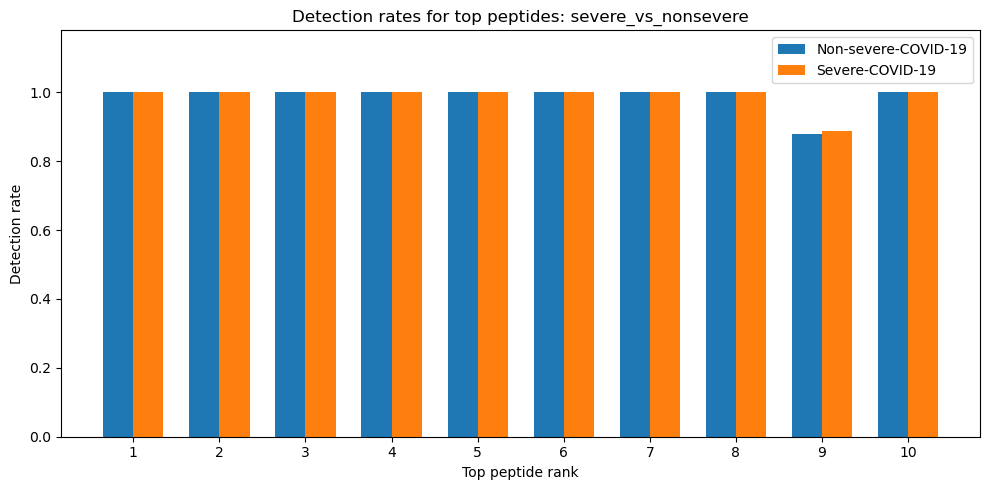

Saved: data\processed\stage2\severe_vs_nonsevere_top_peptides_detection_rates.png


In [16]:
def plot_detection_rates(task_name, missingness_df, top_n=10):
    df = missingness_df[
        (missingness_df["task"] == task_name) &
        (missingness_df["status"] == "ok")
    ].head(top_n).copy()
    
    x = np.arange(len(df))
    width = 0.35
    
    plt.figure(figsize=(10, 5))
    plt.bar(
        x - width / 2,
        df["class0_detection_rate"],
        width,
        label=df["class0_label"].iloc[0],
    )
    plt.bar(
        x + width / 2,
        df["class1_detection_rate"],
        width,
        label=df["class1_label"].iloc[0],
    )
    
    plt.ylabel("Detection rate")
    plt.xlabel("Top peptide rank")
    plt.title(f"Detection rates for top peptides: {task_name}")
    plt.xticks(x, df["rank"])
    plt.ylim(0, 1.18)
    plt.legend()
    plt.tight_layout()

    out_path = PROCESSED_DIR / f"{task_name}_top_peptides_detection_rates.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    return out_path

for task_name in TASK_NAMES:
    path = plot_detection_rates(task_name, missingness_df, top_n=10)
    print("Saved:", path)

Boxplots for top peptides

C:\Users\Selina\AppData\Local\Temp\ipykernel_27480\1392504333.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


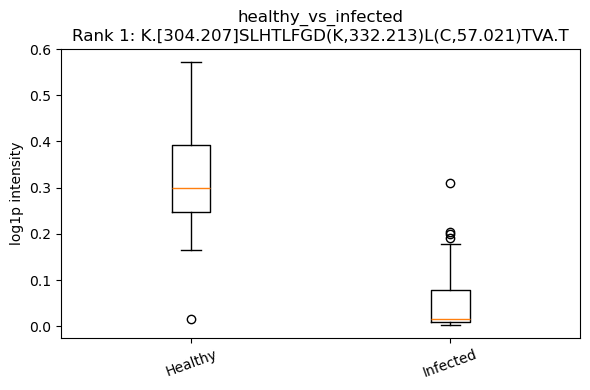

C:\Users\Selina\AppData\Local\Temp\ipykernel_27480\1392504333.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


saved: data\processed\stage2\healthy_vs_infected_boxplot_rank1.png


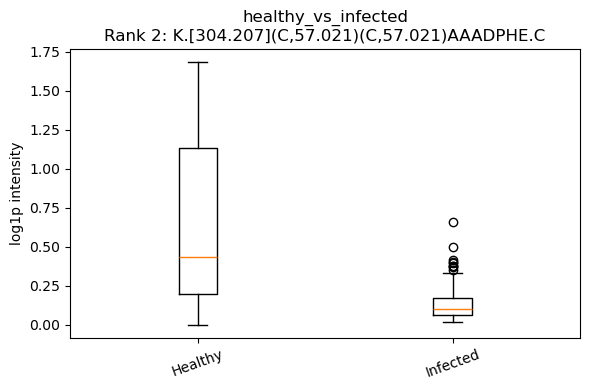

saved: data\processed\stage2\healthy_vs_infected_boxplot_rank2.png


C:\Users\Selina\AppData\Local\Temp\ipykernel_27480\1392504333.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


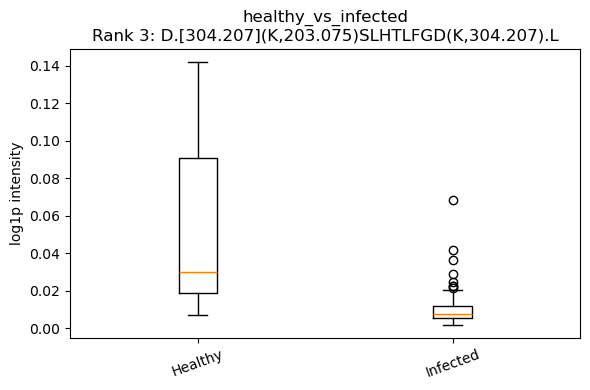

saved: data\processed\stage2\healthy_vs_infected_boxplot_rank3.png


C:\Users\Selina\AppData\Local\Temp\ipykernel_27480\1392504333.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


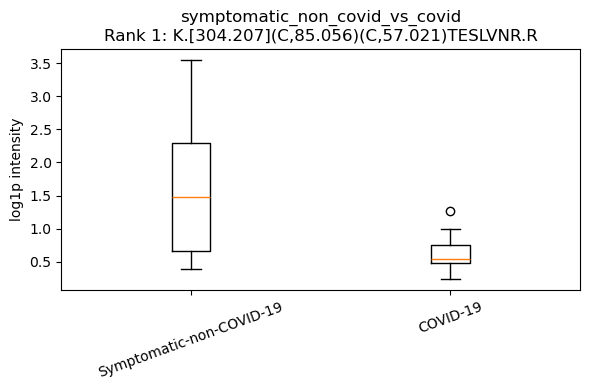

saved: data\processed\stage2\symptomatic_non_covid_vs_covid_boxplot_rank1.png


C:\Users\Selina\AppData\Local\Temp\ipykernel_27480\1392504333.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


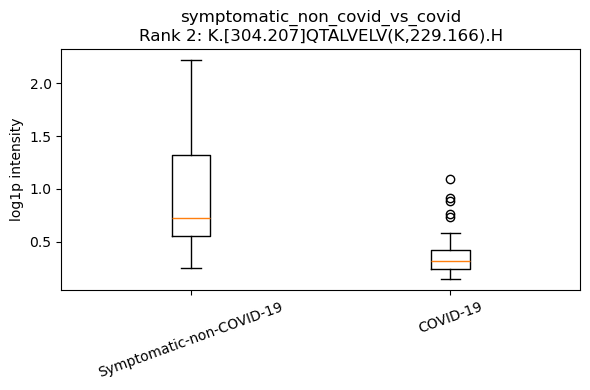

saved: data\processed\stage2\symptomatic_non_covid_vs_covid_boxplot_rank2.png


C:\Users\Selina\AppData\Local\Temp\ipykernel_27480\1392504333.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


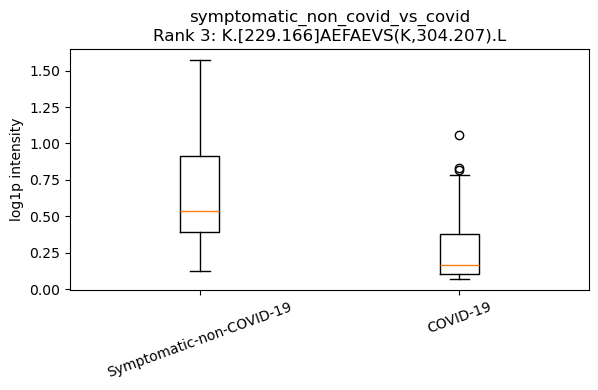

C:\Users\Selina\AppData\Local\Temp\ipykernel_27480\1392504333.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


saved: data\processed\stage2\symptomatic_non_covid_vs_covid_boxplot_rank3.png


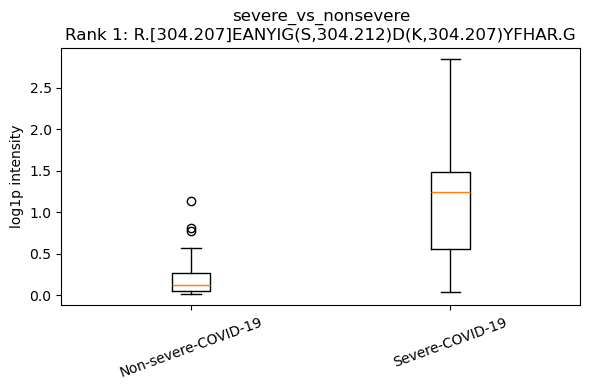

C:\Users\Selina\AppData\Local\Temp\ipykernel_27480\1392504333.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


saved: data\processed\stage2\severe_vs_nonsevere_boxplot_rank1.png


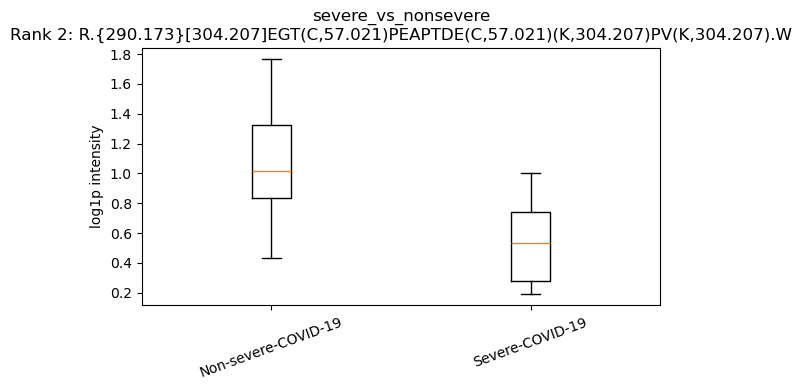

saved: data\processed\stage2\severe_vs_nonsevere_boxplot_rank2.png


C:\Users\Selina\AppData\Local\Temp\ipykernel_27480\1392504333.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


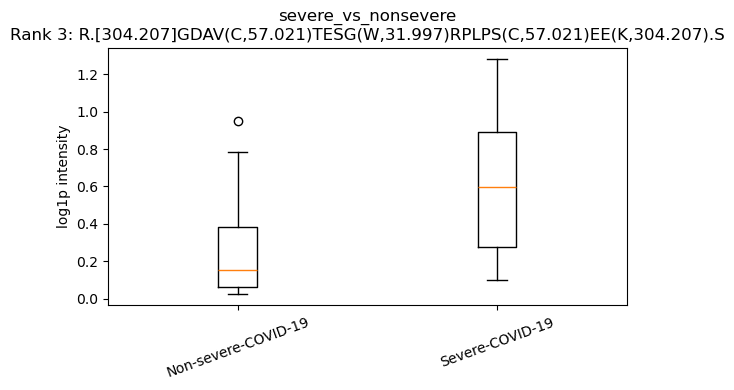

saved: data\processed\stage2\severe_vs_nonsevere_boxplot_rank3.png


In [17]:
def plot_top_peptide_boxplots(task_name, peptide_da_df, task_data, top_n=3):
    data = task_data[task_name]
    X_log = data["X_log"]
    y = data["y"]
    config = data["config"]
    
    df = peptide_da_df[
        (peptide_da_df["task"] == task_name) &
        (peptide_da_df["status"] == "ok")
    ].head(top_n)
    
    for _, row in df.iterrows():
        peptide = row["peptide_variant"]
        
        group0 = X_log.loc[y == 0, peptide].dropna()
        group1 = X_log.loc[y == 1, peptide].dropna()
        
        plt.figure(figsize=(6, 4))
        plt.boxplot(
            [group0, group1],
            labels=[config["negative_label"], config["positive_label"]],
        )
        plt.ylabel("log1p intensity")
        plt.title(f"{task_name}\nRank {row['rank']}: {peptide}")
        plt.xticks(rotation=20)
        plt.tight_layout()

        out_path = PROCESSED_DIR / f"{task_name}_boxplot_rank{row['rank']}.png"
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.show()
        print("saved:",out_path)
    

for task_name in TASK_NAMES:
    plot_top_peptide_boxplots(task_name, peptide_da_df, task_data, top_n=3)

## Part D：Modified vs unmodified / predominant variant comparison

Get base amino acid sequence

In [18]:
def strip_flanking_residues(peptide):
    parts = peptide.split(".")
    if len(parts) == 3:
        return parts[1]
    return peptide


def get_base_sequence(peptide):
    core = strip_flanking_residues(peptide)
    
    # Remove [304.207]-style annotations
    core = re.sub(r"\[[^\]]+\]", "", core)
    
    # Convert (K,304.207) -> K, (C,57.021) -> C
    core = re.sub(r"\(([A-Z]),[^)]+\)", r"\1", core)
    
    # Remove {290.173}-style annotations
    core = re.sub(r"\{[^}]+\}", "", core)
    
    # Keep amino acid letters only
    core = "".join(re.findall(r"[A-Z]", core))
    
    return core


def is_modified(peptide):
    return bool(re.search(r"[\[\(\{]", strip_flanking_residues(peptide)))


top_features["base_sequence"] = top_features["peptide_variant"].apply(get_base_sequence)
top_features["is_modified"] = top_features["peptide_variant"].apply(is_modified)

top_features[["peptide_variant", "base_sequence", "is_modified"]].head()

,peptide_variant,base_sequence,is_modified
0,"K.[304.207]SLHTLFGD(K,332.213)L(C,57.021)TVA.T",KSLHTLFGDKLCTVAT,True
1,"K.[304.207](C,57.021)(C,57.021)AAADPHE.C",KCCAAADPHEC,True
2,"D.[304.207](K,203.075)SLHTLFGD(K,304.207).L",DKSLHTLFGDKL,True
3,"K.[304.207]L(K,331.18)E(C,57.021)(C,57.021)E(K...",KLKECCEKPLLEKS,True
4,"K.[304.207]ADSVVDLLSYNV(Q,303.212)GSGETTYDH(K,...",KADSVVDLLSYNVQGSGETTYDHKN,True


Find same-sequence variants

In [19]:
all_feature_cols = sample_log_matrix.columns

feature_variant_table = pd.DataFrame({
    "peptide_variant": list(all_feature_cols),
})

feature_variant_table["base_sequence"] = feature_variant_table["peptide_variant"].apply(get_base_sequence)
feature_variant_table["is_modified"] = feature_variant_table["peptide_variant"].apply(is_modified)

feature_variant_table.head()

,peptide_variant,base_sequence,is_modified
0,K.[304.207]LYQPEYQEVSTEEQR.E,KLYQPEYQEVSTEEQRE,True
1,"K.[304.207]H(G,304.213)TDDGVVWMNW(K,304.207).G",KHGTDDGVVWMNWKG,True
2,"R.[304.207]DDTV(C,57.021)LA(K,304.207)LHDR.N",RDDTVCLAKLHDRN,True
3,"R.[304.207]QQQHLFGSNVTD(C,57.021)SGNF(C,57.021...",RQQQHLFGSNVTDCSGNFCLFRS,True
4,"-.[304.207](Q,-17.027)QQHLFGSNVTD(C,57.021)SGN...",QQQHLFGSNVTDCSGNFCLFRS,True


In [20]:
variant_match_rows = []

for _, row in top_features.iterrows():
    task_name = row["task"]
    top_variant = row["peptide_variant"]
    base_seq = row["base_sequence"]
    
    same_seq_variants = feature_variant_table[
        feature_variant_table["base_sequence"] == base_seq
    ].copy()
    
    for _, v in same_seq_variants.iterrows():
        variant_match_rows.append({
            "task": task_name,
            "top_rank": row["rank"],
            "top_variant": top_variant,
            "base_sequence": base_seq,
            "matched_variant": v["peptide_variant"],
            "matched_is_modified": v["is_modified"],
            "is_top_variant": v["peptide_variant"] == top_variant,
        })

variant_matches_df = pd.DataFrame(variant_match_rows)

variant_matches_df.to_csv(
    PROCESSED_DIR / "modified_vs_unmodified_variant_matches.csv",
    index=False
)

variant_matches_df.head()

,task,top_rank,top_variant,base_sequence,matched_variant,matched_is_modified,is_top_variant
0,healthy_vs_infected,1,"K.[304.207]SLHTLFGD(K,332.213)L(C,57.021)TVA.T",KSLHTLFGDKLCTVAT,"K.[304.207]SLHTLFGD(K,351.665)L(C,57.021)TVA.T",True,False
1,healthy_vs_infected,1,"K.[304.207]SLHTLFGD(K,332.213)L(C,57.021)TVA.T",KSLHTLFGDKLCTVAT,"K.[304.207]SLHTLFGD(K,338.246)L(C,57.021)TVA.T",True,False
2,healthy_vs_infected,1,"K.[304.207]SLHTLFGD(K,332.213)L(C,57.021)TVA.T",KSLHTLFGDKLCTVAT,"K.[304.207]SLHTLFGD(K,332.213)L(C,57.021)TVA.T",True,True
3,healthy_vs_infected,1,"K.[304.207]SLHTLFGD(K,332.213)L(C,57.021)TVA.T",KSLHTLFGDKLCTVAT,"K.[304.207]SLHTLFGD(K,330.707)L(C,57.021)TVA.T",True,False
4,healthy_vs_infected,1,"K.[304.207]SLHTLFGD(K,332.213)L(C,57.021)TVA.T",KSLHTLFGDKLCTVAT,"K.[304.207]SLHTLFGD(K,304.207)L(C,57.021)TVA.T",True,False


In [21]:
def run_single_feature_da(task_name, feature, X_log, X_missing, y, config):
    if feature not in X_log.columns:
        return None
    
    values = X_log[feature]
    group0 = values[y == 0].dropna()
    group1 = values[y == 1].dropna()
    
    if len(group0) < 2 or len(group1) < 2:
        return None
    
    t_stat, t_p = ttest_ind(group0, group1, equal_var=False)
    u_stat, u_p = mannwhitneyu(group0, group1, alternative="two-sided")
    
    class0_missing_rate = X_missing.loc[y == 0, feature].isna().mean()
    class1_missing_rate = X_missing.loc[y == 1, feature].isna().mean()
    
    mean0 = group0.mean()
    mean1 = group1.mean()
    diff = mean1 - mean0
    
    if diff > 0:
        direction = f"higher_in_{config['positive_label']}"
    elif diff < 0:
        direction = f"higher_in_{config['negative_label']}"
    else:
        direction = "no_difference"
    
    return {
        "task": task_name,
        "feature": feature,
        "class0_mean_log1p": mean0,
        "class1_mean_log1p": mean1,
        "mean_diff_class1_minus_class0": diff,
        "direction": direction,
        "t_test_p": t_p,
        "mannwhitney_p": u_p,
        "class0_missing_rate": class0_missing_rate,
        "class1_missing_rate": class1_missing_rate,
        "overall_detection_rate": 1 - X_missing[feature].isna().mean(),
    }


modified_vs_predominant_rows = []

for _, row in top_features.iterrows():
    task_name = row["task"]
    top_variant = row["peptide_variant"]
    base_seq = row["base_sequence"]
    
    data = task_data[task_name]
    X_log = data["X_log"]
    X_missing = data["X_missing"]
    y = data["y"]
    config = data["config"]
    
    same_seq_variants = feature_variant_table[
        feature_variant_table["base_sequence"] == base_seq
    ].copy()
    
    if same_seq_variants.empty:
        continue
    
    same_seq_variants["detection_rate"] = same_seq_variants["peptide_variant"].apply(
        lambda f: 1 - X_missing[f].isna().mean() if f in X_missing.columns else np.nan
    )
    
    # Prefer truly unmodified variant if available; otherwise choose most predominant variant.
    unmodified_variants = same_seq_variants[
        same_seq_variants["is_modified"] == False
    ].copy()
    
    if len(unmodified_variants) > 0:
        comparison_variant = (
            unmodified_variants
            .sort_values("detection_rate", ascending=False)
            .iloc[0]["peptide_variant"]
        )
        comparison_type = "unmodified_variant"
    else:
        comparison_variant = (
            same_seq_variants
            .sort_values("detection_rate", ascending=False)
            .iloc[0]["peptide_variant"]
        )
        comparison_type = "predominant_same_sequence_variant"
    
    top_da = run_single_feature_da(task_name, top_variant, X_log, X_missing, y, config)
    comp_da = run_single_feature_da(task_name, comparison_variant, X_log, X_missing, y, config)
    
    if top_da is None or comp_da is None:
        continue
    
    modified_vs_predominant_rows.append({
        "task": task_name,
        "top_rank": row["rank"],
        "base_sequence": base_seq,
        "top_variant": top_variant,
        "top_is_modified": is_modified(top_variant),
        "comparison_variant": comparison_variant,
        "comparison_type": comparison_type,
        "n_same_sequence_variants": len(same_seq_variants),
        
        "top_direction": top_da["direction"],
        "top_t_test_p": top_da["t_test_p"],
        "top_mannwhitney_p": top_da["mannwhitney_p"],
        "top_mean_diff": top_da["mean_diff_class1_minus_class0"],
        "top_detection_rate": top_da["overall_detection_rate"],
        
        "comparison_direction": comp_da["direction"],
        "comparison_t_test_p": comp_da["t_test_p"],
        "comparison_mannwhitney_p": comp_da["mannwhitney_p"],
        "comparison_mean_diff": comp_da["mean_diff_class1_minus_class0"],
        "comparison_detection_rate": comp_da["overall_detection_rate"],
        
        "same_direction": top_da["direction"] == comp_da["direction"],
    })

modified_vs_predominant_df = pd.DataFrame(modified_vs_predominant_rows)

modified_vs_predominant_df.to_csv(
    PROCESSED_DIR / "modified_vs_predominant_DA_comparison.csv",
    index=False
)

modified_vs_predominant_df.head()

,task,top_rank,base_sequence,top_variant,top_is_modified,comparison_variant,comparison_type,n_same_sequence_variants,top_direction,top_t_test_p,top_mannwhitney_p,top_mean_diff,top_detection_rate,comparison_direction,comparison_t_test_p,comparison_mannwhitney_p,comparison_mean_diff,comparison_detection_rate,same_direction
0,healthy_vs_infected,1,KSLHTLFGDKLCTVAT,"K.[304.207]SLHTLFGD(K,332.213)L(C,57.021)TVA.T",True,"K.[304.207]SLHTLFGD(K,330.707)L(C,57.021)TVA.T",predominant_same_sequence_variant,6,higher_in_Healthy,2.348645e-09,1.084253e-10,-0.262285,1.000000,higher_in_Healthy,2.624697e-05,4.153143e-10,-0.211486,1.000000,True
1,healthy_vs_infected,2,KCCAAADPHEC,"K.[304.207](C,57.021)(C,57.021)AAADPHE.C",True,"K.[304.207](C,57.021)(C,57.021)AAADPHE.C",predominant_same_sequence_variant,3,higher_in_Healthy,3.783922e-04,9.565974e-06,-0.512433,0.988889,higher_in_Healthy,3.783922e-04,9.565974e-06,-0.512433,0.988889,True
2,healthy_vs_infected,3,DKSLHTLFGDKL,"D.[304.207](K,203.075)SLHTLFGD(K,304.207).L",True,"D.[304.207](K,292.58)SLHTLFGD(K,304.207).L",predominant_same_sequence_variant,10,higher_in_Healthy,2.243013e-04,2.956214e-08,-0.045118,1.000000,higher_in_Infected,6.067253e-01,6.088732e-01,0.021687,1.000000,False
3,healthy_vs_infected,4,KLKECCEKPLLEKS,"K.[304.207]L(K,331.18)E(C,57.021)(C,57.021)E(K...",True,"K.{14.997}[304.207]L(K,304.207)E(C,57.021)(C,5...",predominant_same_sequence_variant,31,higher_in_Healthy,4.410105e-04,5.082513e-09,-0.107214,1.000000,higher_in_Healthy,4.192227e-01,4.113566e-01,-0.039781,1.000000,True
4,healthy_vs_infected,5,KADSVVDLLSYNVQGSGETTYDHKN,"K.[304.207]ADSVVDLLSYNV(Q,303.212)GSGETTYDH(K,...",True,"K.[304.207]ADSVVDLLSYNV(Q,303.212)GSGETTYDH(K,...",predominant_same_sequence_variant,2,higher_in_Infected,6.984882e-11,1.100510e-07,0.258317,1.000000,higher_in_Infected,6.984882e-11,1.100510e-07,0.258317,1.000000,True


In [22]:
df = pd.read_csv(PROCESSED_DIR / "modified_vs_predominant_DA_comparison.csv")

summary = {
    "Top modified variants compared": len(df),
    "Compared to true unmodified variant": (df["comparison_type"] == "unmodified_variant").sum(),
    "Compared to predominant same-sequence variant": (df["comparison_type"] == "predominant_same_sequence_variant").sum(),
    "Same DA direction as comparison variant": df["same_direction"].sum(),
    "Different DA direction from comparison variant": (~df["same_direction"]).sum(),
}
summary

{'Top modified variants compared': 30,
 'Compared to true unmodified variant': np.int64(0),
 'Compared to predominant same-sequence variant': np.int64(30),
 'Same DA direction as comparison variant': np.int64(21),
 'Different DA direction from comparison variant': np.int64(9)}

## Part E：Protein-level DA


In [23]:
PROTEIN_DIR = "protein_level" 

# 1. Build peptide-to-protein mapping
PROTEIN_UNIQUE_COL = "Peptide_maps_uniquely_to_protein"
PRIMARY_PROTEIN_COL = "Top_canonical_protein"
FALLBACK_PROTEIN_COL = "Top_protein"
ALL_PROTEINS_COL = "Proteins"

required_protein_cols = [
    "Peptide",
    PROTEIN_UNIQUE_COL,
    PRIMARY_PROTEIN_COL,
    FALLBACK_PROTEIN_COL,
    ALL_PROTEINS_COL,
]

missing_required_cols = [c for c in required_protein_cols if c not in raw_df.columns]

if missing_required_cols:
    raise ValueError(f"Missing required protein mapping columns: {missing_required_cols}")

protein_map = raw_df[required_protein_cols].copy()
protein_map = protein_map.drop_duplicates()
protein_map = protein_map.rename(columns={"Peptide": "peptide_variant"})


def parse_unique_flag(x):
    """
    Convert raw unique-mapping flag to boolean.
    Handles common formats: True/False, 1/0, yes/no.
    """
    if pd.isna(x):
        return False
    
    s = str(x).strip().lower()
    
    return s in {"true", "1", "yes", "y"}


protein_map["maps_uniquely_to_protein"] = protein_map[PROTEIN_UNIQUE_COL].apply(parse_unique_flag)

# Prefer canonical protein if available, otherwise fall back to Top_protein, then Proteins.
protein_map["protein"] = (
    protein_map[PRIMARY_PROTEIN_COL]
    .replace("", np.nan)
    .fillna(protein_map[FALLBACK_PROTEIN_COL].replace("", np.nan))
    .fillna(protein_map[ALL_PROTEINS_COL].replace("", np.nan))
)

protein_map["mapping_type"] = np.where(
    protein_map["maps_uniquely_to_protein"],
    "unique",
    "multiple_or_ambiguous"
)

protein_map.to_csv(
    PROCESSED_DIR / PROTEIN_DIR / "peptide_protein_mapping.csv",
    index=False
)

print("protein_map shape:", protein_map.shape)
print(protein_map["mapping_type"].value_counts(dropna=False))
protein_map.head()

protein_map shape: (101461, 8)
mapping_type
multiple_or_ambiguous    74512
unique                   26949
Name: count, dtype: int64


,peptide_variant,Peptide_maps_uniquely_to_protein,Top_canonical_protein,Top_protein,Proteins,maps_uniquely_to_protein,protein,mapping_type
0,"K.[304.207]GARLIPEMDQIFTEVEMTTLE(K,304.207).V",0,NaN,NaN,sp|Q9Y4L1|HYOU1_HUMAN; tr|A0A087X054|A0A087X05...,False,sp|Q9Y4L1|HYOU1_HUMAN; tr|A0A087X054|A0A087X05...,multiple_or_ambiguous
1,"I.[304.207]FTEVEMTTLE(K,304.207).V",0,NaN,NaN,sp|Q9Y4L1|HYOU1_HUMAN; tr|A0A087X054|A0A087X05...,False,sp|Q9Y4L1|HYOU1_HUMAN; tr|A0A087X054|A0A087X05...,multiple_or_ambiguous
2,K.[304.207]LYQPEYQEVSTEEQR.E,0,NaN,NaN,sp|Q9Y4L1|HYOU1_HUMAN; tr|A0A087X054|A0A087X05...,False,sp|Q9Y4L1|HYOU1_HUMAN; tr|A0A087X054|A0A087X05...,multiple_or_ambiguous
3,"K.[304.207]AANSLEAFIFETQD(K,304.207).L",0,NaN,NaN,sp|Q9Y4L1|HYOU1_HUMAN; tr|A0A087X054|A0A087X05...,False,sp|Q9Y4L1|HYOU1_HUMAN; tr|A0A087X054|A0A087X05...,multiple_or_ambiguous
4,"R.[304.207]YSHDF(N,-56.985)FH.I",0,NaN,NaN,sp|Q9Y4L1-2|HYOU1_HUMAN; sp|Q9Y4L1|HYOU1_HUMAN...,False,sp|Q9Y4L1-2|HYOU1_HUMAN; sp|Q9Y4L1|HYOU1_HUMAN...,multiple_or_ambiguous


In [24]:
# 2. Merge protein mapping into top-feature DA results

peptide_da_with_protein = peptide_da_df.merge(
    protein_map[
        [
            "peptide_variant",
            "protein",
            "mapping_type",
            "maps_uniquely_to_protein",
            PRIMARY_PROTEIN_COL,
            FALLBACK_PROTEIN_COL,
            ALL_PROTEINS_COL,
        ]
    ],
    on="peptide_variant",
    how="left",
)

peptide_da_with_protein.to_csv(
    PROCESSED_DIR / PROTEIN_DIR / "peptide_DA_with_protein_mapping.csv",
    index=False,
)

print("peptide_da_with_protein shape:", peptide_da_with_protein.shape)
print(peptide_da_with_protein["mapping_type"].value_counts(dropna=False))
peptide_da_with_protein.head()

peptide_da_with_protein shape: (30, 31)
mapping_type
multiple_or_ambiguous    24
unique                    6
Name: count, dtype: int64


,task,rank,peptide_variant,coefficient,class0_label,class1_label,class0_n,class1_n,class0_mean_log1p,class1_mean_log1p,class0_median_log1p,class1_median_log1p,mean_diff_class1_minus_class0,direction,t_stat,t_test_p,mannwhitney_u,mannwhitney_p,class0_missing_rate,class1_missing_rate,missingness_flag,status,t_test_fdr,mannwhitney_fdr,DA_call,protein,mapping_type,maps_uniquely_to_protein,Top_canonical_protein,Top_protein,Proteins
0,healthy_vs_infected,1,"K.[304.207]SLHTLFGD(K,332.213)L(C,57.021)TVA.T",0.44,Healthy,Infected,22,68,0.312143,0.049858,0.299432,0.016282,-0.262285,higher_in_Healthy,9.130116,2.348645e-09,1436.0,1.084253e-10,0.000000,0.0,acceptable,ok,5.871611e-09,1.084253e-09,strong_DA_FDR,sp|P02768|ALBU_HUMAN,multiple_or_ambiguous,False,sp|P02768|ALBU_HUMAN,sp|P02768|ALBU_HUMAN,sp|P02768-3|ALBU_HUMAN; sp|P02768|ALBU_HUMAN; ...
1,healthy_vs_infected,2,"K.[304.207](C,57.021)(C,57.021)AAADPHE.C",0.40,Healthy,Infected,22,68,0.661065,0.148631,0.436150,0.101691,-0.512433,higher_in_Healthy,4.199347,3.783922e-04,1220.0,9.565974e-06,0.045455,0.0,acceptable,ok,4.204358e-04,9.565974e-06,strong_DA_FDR,sp|P02768|ALBU_HUMAN,multiple_or_ambiguous,False,sp|P02768|ALBU_HUMAN,sp|P02768|ALBU_HUMAN,sp|P02768-2|ALBU_HUMAN; sp|P02768-3|ALBU_HUMAN...
2,healthy_vs_infected,3,"D.[304.207](K,203.075)SLHTLFGD(K,304.207).L",0.40,Healthy,Infected,22,68,0.055877,0.010760,0.029656,0.007426,-0.045118,higher_in_Healthy,4.417698,2.243013e-04,1339.0,2.956214e-08,0.000000,0.0,acceptable,ok,2.803766e-04,7.390534e-08,strong_DA_FDR,sp|P02768|ALBU_HUMAN,multiple_or_ambiguous,False,sp|P02768|ALBU_HUMAN,sp|P02768|ALBU_HUMAN,sp|P02768-3|ALBU_HUMAN; sp|P02768|ALBU_HUMAN; ...
3,healthy_vs_infected,4,"K.[304.207]L(K,331.18)E(C,57.021)(C,57.021)E(K...",0.29,Healthy,Infected,22,68,0.133030,0.025816,0.100841,0.019358,-0.107214,higher_in_Healthy,4.146649,4.410105e-04,1371.0,5.082513e-09,0.000000,0.0,acceptable,ok,4.410105e-04,1.694171e-08,strong_DA_FDR,sp|P02768|ALBU_HUMAN,multiple_or_ambiguous,False,sp|P02768|ALBU_HUMAN,sp|P02768|ALBU_HUMAN,sp|P02768-2|ALBU_HUMAN; sp|P02768|ALBU_HUMAN; ...
4,healthy_vs_infected,5,"K.[304.207]ADSVVDLLSYNV(Q,303.212)GSGETTYDH(K,...",0.26,Healthy,Infected,22,68,0.111080,0.369397,0.083330,0.293272,0.258317,higher_in_Infected,-7.420132,6.984882e-11,182.0,1.100510e-07,0.000000,0.0,acceptable,ok,2.328294e-10,1.572156e-07,strong_DA_FDR,sp|P04114|APOB_HUMAN,unique,True,sp|P04114|APOB_HUMAN,sp|P04114|APOB_HUMAN,sp|P04114|APOB_HUMAN


In [25]:
# 3. Quick protein-level majority rule using selected top features only

def protein_majority_rule_top_features(da_df, p_col="mannwhitney_fdr", alpha=0.05):
    rows = []
    
    usable = da_df[
        (da_df["status"] == "ok") &
        (da_df["mapping_type"] == "unique") &
        (da_df["protein"].notna())
    ].copy()
    
    for (task, protein), group in usable.groupby(["task", "protein"]):
        n_total = len(group)
        
        sig_mask = group[p_col] < alpha
        sig_group = group[sig_mask]
        n_sig = len(sig_group)
        
        if n_sig > 0:
            direction_counts = sig_group["direction"].value_counts()
            majority_direction = direction_counts.idxmax()
            majority_direction_count = direction_counts.max()
        else:
            majority_direction = "none"
            majority_direction_count = 0
        
        protein_level_effect = (
            n_sig > n_total / 2
            and majority_direction_count == n_sig
            and n_total >= 2
        )
        
        if protein_level_effect:
            evidence = "protein_level_effect_among_top_features"
        elif n_sig > 0 and n_total == 1:
            evidence = "single_top_peptide_evidence_only"
        elif n_sig > 0:
            evidence = "mixed_or_minority_top_peptide_effect"
        else:
            evidence = "no_significant_top_peptide_effect"
        
        rows.append({
            "task": task,
            "protein": protein,
            "n_unique_top_peptides_tested": n_total,
            "n_significant_unique_top_peptides": n_sig,
            "majority_direction": majority_direction,
            "protein_level_effect_among_top_features": protein_level_effect,
            "evidence": evidence,
        })
    
    return pd.DataFrame(rows)


protein_majority_top_df = protein_majority_rule_top_features(
    peptide_da_with_protein,
    p_col="mannwhitney_fdr",
    alpha=0.05,
)

protein_majority_top_df.to_csv(
    PROCESSED_DIR / PROTEIN_DIR / "majority_rule_top_features.csv",
    index=False,
)

protein_majority_top_df

,task,protein,n_unique_top_peptides_tested,n_significant_unique_top_peptides,majority_direction,protein_level_effect_among_top_features,evidence
0,healthy_vs_infected,sp|P01782|HV309_HUMAN,1,1,higher_in_Healthy,False,single_top_peptide_evidence_only
1,healthy_vs_infected,sp|P04114|APOB_HUMAN,2,2,higher_in_Infected,True,protein_level_effect_among_top_features
2,severe_vs_nonsevere,sp|P02750|A2GL_HUMAN,1,1,higher_in_Severe-COVID-19,False,single_top_peptide_evidence_only
3,severe_vs_nonsevere,sp|P02787|TRFE_HUMAN,1,1,higher_in_Non-severe-COVID-19,False,single_top_peptide_evidence_only
4,severe_vs_nonsevere,sp|P0DJI9|SAA2_HUMAN,1,1,higher_in_Severe-COVID-19,False,single_top_peptide_evidence_only


In [26]:
# 4.1. Identify proteins represented by uniquely mapped top features

top_feature_unique_proteins = (
    peptide_da_with_protein[
        (peptide_da_with_protein["status"] == "ok") &
        (peptide_da_with_protein["maps_uniquely_to_protein"] == True) &
        (peptide_da_with_protein["protein"].notna())
    ]["protein"]
    .dropna()
    .unique()
)

print("Number of proteins represented by uniquely mapped top features:", len(top_feature_unique_proteins))
print(top_feature_unique_proteins[:20])

Number of proteins represented by uniquely mapped top features: 5
<StringArray>
[ 'sp|P04114|APOB_HUMAN', 'sp|P01782|HV309_HUMAN',  'sp|P02787|TRFE_HUMAN',
  'sp|P0DJI9|SAA2_HUMAN',  'sp|P02750|A2GL_HUMAN']
Length: 5, dtype: str


In [27]:
# 4.2. Build retained peptide feature-to-protein table

all_retained_features = pd.DataFrame({
    "peptide_variant": list(sample_log_matrix.columns)
})

all_feature_protein_map = all_retained_features.merge(
    protein_map[
        [
            "peptide_variant",
            "protein",
            "mapping_type",
            "maps_uniquely_to_protein",
            PRIMARY_PROTEIN_COL,
            FALLBACK_PROTEIN_COL,
            ALL_PROTEINS_COL,
        ]
    ],
    on="peptide_variant",
    how="left",
)

all_feature_protein_map.to_csv(
    PROCESSED_DIR / PROTEIN_DIR / "all_retained_features_with_protein_mapping.csv",
    index=False,
)

print("all_feature_protein_map shape:", all_feature_protein_map.shape)
print(all_feature_protein_map["mapping_type"].value_counts(dropna=False))
all_feature_protein_map.head()

all_feature_protein_map shape: (35882, 7)
mapping_type
multiple_or_ambiguous    26930
unique                    8952
Name: count, dtype: int64


,peptide_variant,protein,mapping_type,maps_uniquely_to_protein,Top_canonical_protein,Top_protein,Proteins
0,K.[304.207]LYQPEYQEVSTEEQR.E,sp|Q9Y4L1|HYOU1_HUMAN; tr|A0A087X054|A0A087X05...,multiple_or_ambiguous,False,NaN,NaN,sp|Q9Y4L1|HYOU1_HUMAN; tr|A0A087X054|A0A087X05...
1,"K.[304.207]H(G,304.213)TDDGVVWMNW(K,304.207).G",sp|P02675|FIBB_HUMAN,multiple_or_ambiguous,False,sp|P02675|FIBB_HUMAN,sp|P02675|FIBB_HUMAN,sp|P02675|FIBB_HUMAN; tr|D6REL8|D6REL8_HUMAN
2,"R.[304.207]DDTV(C,57.021)LA(K,304.207)LHDR.N",sp|P02787|TRFE_HUMAN,unique,True,sp|P02787|TRFE_HUMAN,sp|P02787|TRFE_HUMAN,sp|P02787|TRFE_HUMAN
3,"R.[304.207]QQQHLFGSNVTD(C,57.021)SGNF(C,57.021...",sp|P02787|TRFE_HUMAN,unique,True,sp|P02787|TRFE_HUMAN,sp|P02787|TRFE_HUMAN,sp|P02787|TRFE_HUMAN
4,"-.[304.207](Q,-17.027)QQHLFGSNVTD(C,57.021)SGN...",sp|P02787|TRFE_HUMAN,unique,True,sp|P02787|TRFE_HUMAN,sp|P02787|TRFE_HUMAN,sp|P02787|TRFE_HUMAN


In [28]:
# 4.3. Helper function for single-feature DA

def run_single_feature_da1(task_name, feature, X_log, X_missing, y, config):
    """
    Run DA test for one peptide feature in one task.
    
    Uses:
    - log1p intensity matrix for abundance tests
    - zero-to-NaN matrix for missingness/detection rates
    """
    if feature not in X_log.columns:
        return None
    
    values = X_log[feature]
    
    group0 = values[y == 0].dropna()
    group1 = values[y == 1].dropna()
    
    if len(group0) < 2 or len(group1) < 2:
        return None
    
    t_stat, t_p = ttest_ind(group0, group1, equal_var=False)
    u_stat, u_p = mannwhitneyu(group0, group1, alternative="two-sided")
    
    class0_missing_rate = X_missing.loc[y == 0, feature].isna().mean()
    class1_missing_rate = X_missing.loc[y == 1, feature].isna().mean()
    
    class0_detection_rate = 1 - class0_missing_rate
    class1_detection_rate = 1 - class1_missing_rate
    
    mean0 = group0.mean()
    mean1 = group1.mean()
    median0 = group0.median()
    median1 = group1.median()
    
    diff = mean1 - mean0
    
    if diff > 0:
        direction = f"higher_in_{config['positive_label']}"
    elif diff < 0:
        direction = f"higher_in_{config['negative_label']}"
    else:
        direction = "no_difference"
    
    # Same missingness flag logic as top peptide analysis
    if class0_missing_rate > 0.5 or class1_missing_rate > 0.5:
        missingness_flag = "high_missingness"
    elif abs(class1_missing_rate - class0_missing_rate) > 0.3:
        missingness_flag = "detection_driven"
    else:
        missingness_flag = "acceptable"
    
    return {
        "task": task_name,
        "peptide_variant": feature,
        "class0_label": config["negative_label"],
        "class1_label": config["positive_label"],
        "class0_n": len(group0),
        "class1_n": len(group1),
        "class0_mean_log1p": mean0,
        "class1_mean_log1p": mean1,
        "class0_median_log1p": median0,
        "class1_median_log1p": median1,
        "mean_diff_class1_minus_class0": diff,
        "direction": direction,
        "t_stat": t_stat,
        "t_test_p": t_p,
        "mannwhitney_u": u_stat,
        "mannwhitney_p": u_p,
        "class0_missing_rate": class0_missing_rate,
        "class1_missing_rate": class1_missing_rate,
        "class0_detection_rate": class0_detection_rate,
        "class1_detection_rate": class1_detection_rate,
        "missingness_flag": missingness_flag,
    }

In [29]:
# 4.4. Run DA for all uniquely mapped retained peptides from top-feature proteins

all_unique_peptide_da_rows = []

for task_name in TASK_NAMES:
    print(f"\nRunning all-unique peptide DA for task: {task_name}")
    
    data = task_data[task_name]
    X_log = data["X_log"]
    X_missing = data["X_missing"]
    y = data["y"]
    config = data["config"]
    
    candidate_features = all_feature_protein_map[
        (all_feature_protein_map["maps_uniquely_to_protein"] == True) &
        (all_feature_protein_map["protein"].isin(top_feature_unique_proteins)) &
        (all_feature_protein_map["peptide_variant"].isin(X_log.columns))
    ].copy()
    
    print("Candidate uniquely mapped retained peptides:", len(candidate_features))
    
    for _, frow in candidate_features.iterrows():
        feature = frow["peptide_variant"]
        protein = frow["protein"]
        
        da = run_single_feature_da1(
            task_name=task_name,
            feature=feature,
            X_log=X_log,
            X_missing=X_missing,
            y=y,
            config=config,
        )
        
        if da is None:
            continue
        
        da["protein"] = protein
        da["mapping_type"] = frow["mapping_type"]
        da["maps_uniquely_to_protein"] = frow["maps_uniquely_to_protein"]
        
        all_unique_peptide_da_rows.append(da)

all_unique_peptide_da_df = pd.DataFrame(all_unique_peptide_da_rows)

print("\nAll unique peptide DA shape:", all_unique_peptide_da_df.shape)
all_unique_peptide_da_df.head()


Running all-unique peptide DA for task: healthy_vs_infected
Candidate uniquely mapped retained peptides: 1401

Running all-unique peptide DA for task: symptomatic_non_covid_vs_covid
Candidate uniquely mapped retained peptides: 1401

Running all-unique peptide DA for task: severe_vs_nonsevere
Candidate uniquely mapped retained peptides: 1401

All unique peptide DA shape: (4203, 24)


,task,peptide_variant,class0_label,class1_label,class0_n,class1_n,class0_mean_log1p,class1_mean_log1p,class0_median_log1p,class1_median_log1p,mean_diff_class1_minus_class0,direction,t_stat,t_test_p,mannwhitney_u,mannwhitney_p,class0_missing_rate,class1_missing_rate,class0_detection_rate,class1_detection_rate,missingness_flag,protein,mapping_type,maps_uniquely_to_protein
0,healthy_vs_infected,"R.[304.207]DDTV(C,57.021)LA(K,304.207)LHDR.N",Healthy,Infected,22,68,0.310913,0.247412,0.112057,0.137872,-0.063501,higher_in_Healthy,0.733963,0.469157,781.5,0.750087,0.409091,0.367647,0.590909,0.632353,acceptable,sp|P02787|TRFE_HUMAN,unique,True
1,healthy_vs_infected,"R.[304.207]QQQHLFGSNVTD(C,57.021)SGNF(C,57.021...",Healthy,Infected,22,68,0.145641,0.119713,0.080827,0.062333,-0.025928,higher_in_Healthy,0.498332,0.621844,960.0,0.047066,0.000000,0.000000,1.000000,1.000000,acceptable,sp|P02787|TRFE_HUMAN,unique,True
2,healthy_vs_infected,"-.[304.207](Q,-17.027)QQHLFGSNVTD(C,57.021)SGN...",Healthy,Infected,22,68,0.309233,0.226974,0.220897,0.171502,-0.082259,higher_in_Healthy,1.093842,0.282802,860.0,0.282997,0.318182,0.382353,0.681818,0.617647,acceptable,sp|P02787|TRFE_HUMAN,unique,True
3,healthy_vs_infected,"K.[304.207]DLLFRDDTV(C,57.021)L(A,304.58)(K,30...",Healthy,Infected,22,68,0.346060,0.279007,0.300055,0.294002,-0.067053,higher_in_Healthy,1.003162,0.323637,843.0,0.370940,0.272727,0.250000,0.727273,0.750000,acceptable,sp|P02787|TRFE_HUMAN,unique,True
4,healthy_vs_infected,"R.[304.207]DDTV(C,57.021)LA(K,632.887)LHDR.N",Healthy,Infected,22,68,0.146655,0.247447,0.044606,0.150237,0.100792,higher_in_Infected,-1.891077,0.063213,646.0,0.312702,0.500000,0.470588,0.500000,0.529412,acceptable,sp|P02787|TRFE_HUMAN,unique,True


In [30]:
# 4.5. FDR correction for all unique peptide DA tests

all_unique_peptide_da_df["t_test_fdr"] = np.nan
all_unique_peptide_da_df["mannwhitney_fdr"] = np.nan

for task_name in TASK_NAMES:
    mask = all_unique_peptide_da_df["task"] == task_name
    
    if mask.sum() == 0:
        continue
    
    all_unique_peptide_da_df.loc[mask, "t_test_fdr"] = multipletests(
        all_unique_peptide_da_df.loc[mask, "t_test_p"].fillna(1.0),
        method="fdr_bh",
    )[1]
    
    all_unique_peptide_da_df.loc[mask, "mannwhitney_fdr"] = multipletests(
        all_unique_peptide_da_df.loc[mask, "mannwhitney_p"].fillna(1.0),
        method="fdr_bh",
    )[1]


def call_da_for_all_unique(r):
    """
    DA call for all unique peptides.
    Similar to top peptide DA calls, but stricter because this table is used for protein-level rule.
    """
    fdr_sig = (
        pd.notna(r["mannwhitney_fdr"]) and r["mannwhitney_fdr"] < 0.05
    ) or (
        pd.notna(r["t_test_fdr"]) and r["t_test_fdr"] < 0.05
    )
    
    nominal_sig = (
        pd.notna(r["mannwhitney_p"]) and r["mannwhitney_p"] < 0.05
    ) or (
        pd.notna(r["t_test_p"]) and r["t_test_p"] < 0.05
    )
    
    if r["missingness_flag"] in ["high_missingness", "detection_driven"]:
        if nominal_sig:
            return "weak_DA_missingness_caution"
        return "not_DA_missingness_caution"
    
    if fdr_sig:
        return "strong_DA_FDR"
    
    if nominal_sig:
        return "moderate_DA_nominal"
    
    return "not_DA"


all_unique_peptide_da_df["DA_call"] = all_unique_peptide_da_df.apply(
    call_da_for_all_unique,
    axis=1,
)

all_unique_peptide_da_df.to_csv(
    PROCESSED_DIR / PROTEIN_DIR / "all_unique_peptides_for_top_proteins_DA.csv",
    index=False,
)

print(all_unique_peptide_da_df["DA_call"].value_counts(dropna=False))
all_unique_peptide_da_df.head()

DA_call
not_DA                         3839
not_DA_missingness_caution      152
moderate_DA_nominal             132
strong_DA_FDR                    78
weak_DA_missingness_caution       2
Name: count, dtype: int64


,task,peptide_variant,class0_label,class1_label,class0_n,class1_n,class0_mean_log1p,class1_mean_log1p,class0_median_log1p,class1_median_log1p,mean_diff_class1_minus_class0,direction,t_stat,t_test_p,mannwhitney_u,mannwhitney_p,class0_missing_rate,class1_missing_rate,class0_detection_rate,class1_detection_rate,missingness_flag,protein,mapping_type,maps_uniquely_to_protein,t_test_fdr,mannwhitney_fdr,DA_call
0,healthy_vs_infected,"R.[304.207]DDTV(C,57.021)LA(K,304.207)LHDR.N",Healthy,Infected,22,68,0.310913,0.247412,0.112057,0.137872,-0.063501,higher_in_Healthy,0.733963,0.469157,781.5,0.750087,0.409091,0.367647,0.590909,0.632353,acceptable,sp|P02787|TRFE_HUMAN,unique,True,0.967450,0.996548,not_DA
1,healthy_vs_infected,"R.[304.207]QQQHLFGSNVTD(C,57.021)SGNF(C,57.021...",Healthy,Infected,22,68,0.145641,0.119713,0.080827,0.062333,-0.025928,higher_in_Healthy,0.498332,0.621844,960.0,0.047066,0.000000,0.000000,1.000000,1.000000,acceptable,sp|P02787|TRFE_HUMAN,unique,True,0.968991,0.534244,moderate_DA_nominal
2,healthy_vs_infected,"-.[304.207](Q,-17.027)QQHLFGSNVTD(C,57.021)SGN...",Healthy,Infected,22,68,0.309233,0.226974,0.220897,0.171502,-0.082259,higher_in_Healthy,1.093842,0.282802,860.0,0.282997,0.318182,0.382353,0.681818,0.617647,acceptable,sp|P02787|TRFE_HUMAN,unique,True,0.962227,0.937732,not_DA
3,healthy_vs_infected,"K.[304.207]DLLFRDDTV(C,57.021)L(A,304.58)(K,30...",Healthy,Infected,22,68,0.346060,0.279007,0.300055,0.294002,-0.067053,higher_in_Healthy,1.003162,0.323637,843.0,0.370940,0.272727,0.250000,0.727273,0.750000,acceptable,sp|P02787|TRFE_HUMAN,unique,True,0.962227,0.942877,not_DA
4,healthy_vs_infected,"R.[304.207]DDTV(C,57.021)LA(K,632.887)LHDR.N",Healthy,Infected,22,68,0.146655,0.247447,0.044606,0.150237,0.100792,higher_in_Infected,-1.891077,0.063213,646.0,0.312702,0.500000,0.470588,0.500000,0.529412,acceptable,sp|P02787|TRFE_HUMAN,unique,True,0.497535,0.940009,not_DA


In [31]:
# 4.6. Strict protein-level majority rule

def protein_majority_rule_all_unique(
    da_df,
    p_col="mannwhitney_fdr",
    alpha=0.05,
    require_acceptable_missingness=True,
):
    rows = []
    
    if da_df.empty:
        return pd.DataFrame()
    
    for (task, protein), group in da_df.groupby(["task", "protein"]):
        group = group.copy()
        
        # Optional: exclude high-missingness/detection-driven peptides from protein-level majority rule
        if require_acceptable_missingness:
            testable_group = group[group["missingness_flag"] == "acceptable"].copy()
        else:
            testable_group = group.copy()
        
        n_total = len(testable_group)
        
        if n_total == 0:
            rows.append({
                "task": task,
                "protein": protein,
                "n_unique_peptides_tested": 0,
                "n_significant_unique_peptides": 0,
                "majority_direction": "none",
                "protein_level_effect": False,
                "evidence": "no_testable_unique_peptides_after_missingness_filter",
            })
            continue
        
        sig_mask = testable_group[p_col] < alpha
        sig_group = testable_group[sig_mask]
        n_sig = len(sig_group)
        
        if n_sig > 0:
            direction_counts = sig_group["direction"].value_counts()
            majority_direction = direction_counts.idxmax()
            majority_direction_count = direction_counts.max()
        else:
            majority_direction = "none"
            majority_direction_count = 0
        
        # Majority rule:
        # 1. more than half of uniquely mapped peptides are significant
        # 2. all/significant majority has consistent direction
        # 3. at least 2 peptides support protein-level effect
        protein_level_effect = (
            n_sig > n_total / 2
            and majority_direction_count == n_sig
            and n_total >= 2
        )
        
        if protein_level_effect:
            evidence = "protein_level_effect"
        elif n_sig > 0 and n_total == 1:
            evidence = "single_peptide_evidence_only"
        elif n_sig > 0:
            evidence = "mixed_or_minority_peptide_effect"
        else:
            evidence = "no_consistent_protein_level_effect"
        
        rows.append({
            "task": task,
            "protein": protein,
            "n_unique_peptides_tested": n_total,
            "n_significant_unique_peptides": n_sig,
            "fraction_significant_unique_peptides": n_sig / n_total if n_total > 0 else np.nan,
            "majority_direction": majority_direction,
            "protein_level_effect": protein_level_effect,
            "evidence": evidence,
        })
    
    return pd.DataFrame(rows)


protein_majority_all_unique_df = protein_majority_rule_all_unique(
    all_unique_peptide_da_df,
    p_col="mannwhitney_fdr",
    alpha=0.05,
    require_acceptable_missingness=True,
)

protein_majority_all_unique_df.to_csv(
    PROCESSED_DIR / PROTEIN_DIR / "majority_rule_all_unique_peptides.csv",
    index=False,
)

protein_majority_all_unique_df

,task,protein,n_unique_peptides_tested,n_significant_unique_peptides,fraction_significant_unique_peptides,majority_direction,protein_level_effect,evidence
0,healthy_vs_infected,sp|P01782|HV309_HUMAN,10,1,0.100000,higher_in_Healthy,False,mixed_or_minority_peptide_effect
1,healthy_vs_infected,sp|P02750|A2GL_HUMAN,33,0,0.000000,none,False,no_consistent_protein_level_effect
2,healthy_vs_infected,sp|P02787|TRFE_HUMAN,881,1,0.001135,higher_in_Healthy,False,mixed_or_minority_peptide_effect
3,healthy_vs_infected,sp|P04114|APOB_HUMAN,428,27,0.063084,higher_in_Infected,False,mixed_or_minority_peptide_effect
4,healthy_vs_infected,sp|P0DJI9|SAA2_HUMAN,15,2,0.133333,higher_in_Infected,False,mixed_or_minority_peptide_effect
5,severe_vs_nonsevere,sp|P01782|HV309_HUMAN,9,0,0.000000,none,False,no_consistent_protein_level_effect
6,severe_vs_nonsevere,sp|P02750|A2GL_HUMAN,33,0,0.000000,none,False,no_consistent_protein_level_effect
7,severe_vs_nonsevere,sp|P02787|TRFE_HUMAN,875,1,0.001143,higher_in_Non-severe-COVID-19,False,mixed_or_minority_peptide_effect
8,severe_vs_nonsevere,sp|P04114|APOB_HUMAN,426,0,0.000000,none,False,no_consistent_protein_level_effect
9,severe_vs_nonsevere,sp|P0DJI9|SAA2_HUMAN,15,2,0.133333,higher_in_Severe-COVID-19,False,mixed_or_minority_peptide_effect


In [33]:
# 4.7. Summary for report

print("Protein-level majority rule summary:")
print(protein_majority_all_unique_df["evidence"].value_counts(dropna=False))

print("\nProteins called as protein-level effects:")
display(
    protein_majority_all_unique_df[
        protein_majority_all_unique_df["protein_level_effect"] == True
    ].sort_values(["task", "fraction_significant_unique_peptides"], ascending=[True, False])
)

print("\nSingle-peptide-only evidence:")
display(
    protein_majority_all_unique_df[
        protein_majority_all_unique_df["evidence"] == "single_peptide_evidence_only"
    ].sort_values(["task", "protein"])
)

print("\nMixed/minority evidence:")
display(
    protein_majority_all_unique_df[
        protein_majority_all_unique_df["evidence"] == "mixed_or_minority_peptide_effect"
    ].sort_values(["task", "protein"])
)

Protein-level majority rule summary:
evidence
no_consistent_protein_level_effect    8
mixed_or_minority_peptide_effect      7
Name: count, dtype: int64

Proteins called as protein-level effects:


,task,protein,n_unique_peptides_tested,n_significant_unique_peptides,fraction_significant_unique_peptides,majority_direction,protein_level_effect,evidence



Single-peptide-only evidence:


,task,protein,n_unique_peptides_tested,n_significant_unique_peptides,fraction_significant_unique_peptides,majority_direction,protein_level_effect,evidence



Mixed/minority evidence:


,task,protein,n_unique_peptides_tested,n_significant_unique_peptides,fraction_significant_unique_peptides,majority_direction,protein_level_effect,evidence
0,healthy_vs_infected,sp|P01782|HV309_HUMAN,10,1,0.100000,higher_in_Healthy,False,mixed_or_minority_peptide_effect
2,healthy_vs_infected,sp|P02787|TRFE_HUMAN,881,1,0.001135,higher_in_Healthy,False,mixed_or_minority_peptide_effect
3,healthy_vs_infected,sp|P04114|APOB_HUMAN,428,27,0.063084,higher_in_Infected,False,mixed_or_minority_peptide_effect
4,healthy_vs_infected,sp|P0DJI9|SAA2_HUMAN,15,2,0.133333,higher_in_Infected,False,mixed_or_minority_peptide_effect
7,severe_vs_nonsevere,sp|P02787|TRFE_HUMAN,875,1,0.001143,higher_in_Non-severe-COVID-19,False,mixed_or_minority_peptide_effect
9,severe_vs_nonsevere,sp|P0DJI9|SAA2_HUMAN,15,2,0.133333,higher_in_Severe-COVID-19,False,mixed_or_minority_peptide_effect
12,symptomatic_non_covid_vs_covid,sp|P02787|TRFE_HUMAN,854,1,0.001171,higher_in_COVID-19,False,mixed_or_minority_peptide_effect
